# CH 6 : SOUND INFERENCE REQUIRES THE CORRECT SAMPLING DISTRIBUTION

> **Idée centrale :** une conclusion statistique n’est valide que si la **distribution d’échantillonnage** utilisée correspond exactement à la **statistique réellement observée**.

Dans un **backtest de règle unique**, la statistique observée est une **moyenne**.

Dans un processus de **data mining**, la statistique observée n’est plus une simple moyenne : c’est le **maximum** parmi beaucoup de moyennes candidates.

Ce notebook illustre pourquoi une **p-value classique** peut devenir trompeuse lorsqu’on sélectionne la meilleure règle après avoir testé plusieurs variantes.


## 1. Le problème EBTA

En trading algorithmique, on peut tester une règle de deux manières très différentes.

| Situation | Ce qu’on observe vraiment | Distribution correcte |
|---|---:|---:|
| **Règle unique** | La moyenne d’une seule règle | Distribution d’une moyenne |
| **Minage de données** | Le maximum parmi plusieurs règles | Distribution du maximum |

Le piège vient du fait que le **maximum** est naturellement plus élevé que la moyenne d’une règle prise isolément.

Même si toutes les règles sont nulles, le meilleur résultat d’un grand ensemble peut sembler impressionnant.


## 2. Intuition statistique

Supposons que toutes les règles testées n’ont aucun pouvoir prédictif réel.

Chaque règle produit une performance historique par hasard.

Si on teste une seule règle, obtenir un profit élevé est rare.

Mais si on teste 50, 100 ou 1 000 règles, il devient beaucoup plus probable qu’une règle affiche un bon résultat par simple chance.

> **Le data mining ne change pas forcément le marché. Il change la statistique que l’on observe.**


## 3. Formulation mathématique simple

Pour une règle unique, on observe une moyenne de rendements :

$$
\bar{r} = \frac{1}{T}\sum_{t=1}^{T} r_t
$$

Sous l’**hypothèse nulle** $H_0$, cette moyenne est supposée être centrée autour de zéro :

$$
H_0 : \mu = 0
$$

Mais si on teste $N$ règles et qu’on garde la meilleure, on observe :

$$
M_N = \max(\bar{r}_1, \bar{r}_2, \ldots, \bar{r}_N)
$$

La distribution de $M_N$ n’est pas centrée sur zéro.

Elle est décalée vers la droite, car le maximum d’un ensemble de valeurs aléatoires est généralement positif.


In [1]:
# Imports de base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)


## 4. Simulation 1 — Règle unique sous hypothèse nulle

On simule une règle de trading sans edge.

Chaque rendement journalier est tiré aléatoirement autour de zéro.

L’objectif est de visualiser la distribution des moyennes obtenues par hasard.


In [2]:
# Paramètres
T = 252              # nombre de jours de trading dans un backtest
n_sim = 20_000       # nombre de mondes simulés
sigma = 0.01         # volatilité journalière hypothétique

# Simulation de n_sim backtests d'une seule règle sans edge
single_rule_returns = rng.normal(loc=0.0, scale=sigma, size=(n_sim, T))
single_rule_means = single_rule_returns.mean(axis=1)

single_rule_summary = pd.Series(single_rule_means).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
single_rule_summary


count    20000.000000
mean         0.000009
std          0.000634
min         -0.003357
1%          -0.001463
5%          -0.001035
50%          0.000009
95%          0.001058
99%          0.001495
max          0.002328
dtype: float64

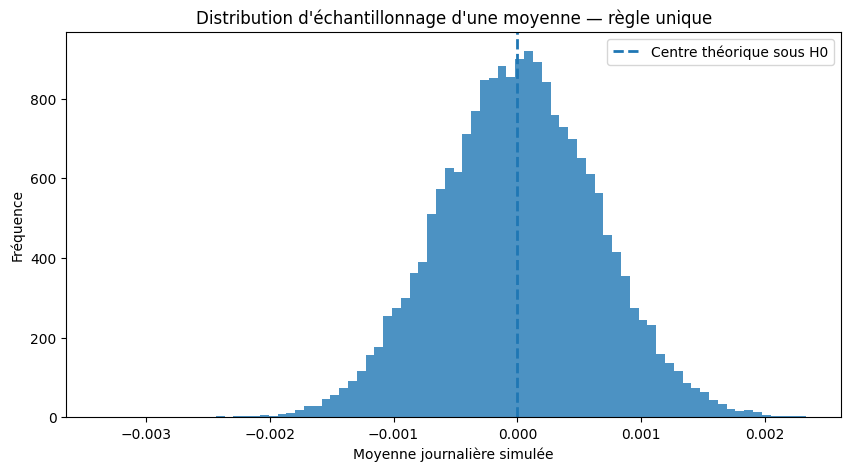

In [3]:
plt.figure(figsize=(10, 5))
plt.hist(single_rule_means, bins=80, alpha=0.8)
plt.axvline(0, linestyle='--', linewidth=2, label='Centre théorique sous H0')
plt.title("Distribution d'échantillonnage d'une moyenne — règle unique")
plt.xlabel('Moyenne journalière simulée')
plt.ylabel('Fréquence')
plt.legend()
plt.show()


## 5. Simulation 2 — Meilleure règle parmi plusieurs règles nulles

Maintenant, on simule un trader qui teste plusieurs règles sans edge.

Chaque règle est nulle, mais le trader sélectionne la meilleure performance historique.

La statistique observée devient donc le **maximum**.


In [4]:
# Paramètres du data mining
N_rules = 50

# n_sim univers, N_rules règles par univers, T jours par règle
mining_returns = rng.normal(loc=0.0, scale=sigma, size=(n_sim, N_rules, T))
rule_means = mining_returns.mean(axis=2)
max_means = rule_means.max(axis=1)

comparison = pd.DataFrame({
    'Distribution': ['Règle unique', f'Maximum parmi {N_rules} règles'],
    'Moyenne de la statistique': [single_rule_means.mean(), max_means.mean()],
    'Médiane': [np.median(single_rule_means), np.median(max_means)],
    'Percentile 95%': [np.percentile(single_rule_means, 95), np.percentile(max_means, 95)],
})
comparison


,Distribution,Moyenne de la statistique,Médiane,Percentile 95%
0,Règle unique,0.000009,0.000009,0.001058
1,Maximum parmi 50 règles,0.001420,0.001391,0.001944


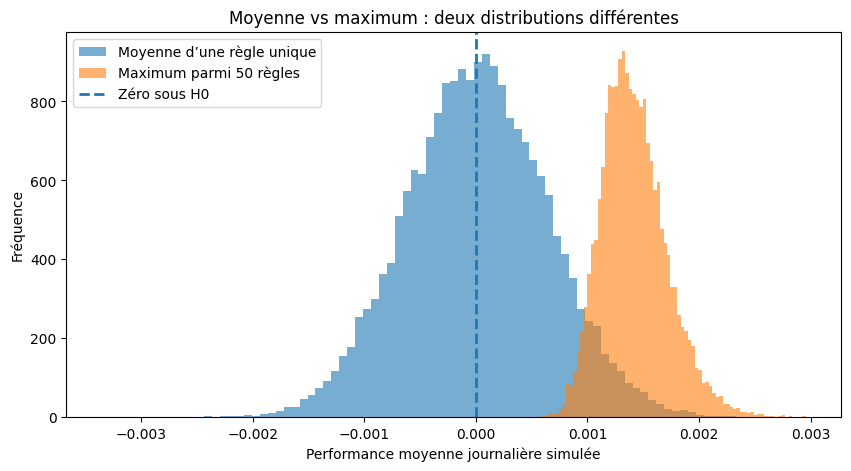

In [5]:
plt.figure(figsize=(10, 5))
plt.hist(single_rule_means, bins=80, alpha=0.6, label='Moyenne d’une règle unique')
plt.hist(max_means, bins=80, alpha=0.6, label=f'Maximum parmi {N_rules} règles')
plt.axvline(0, linestyle='--', linewidth=2, label='Zéro sous H0')
plt.title('Moyenne vs maximum : deux distributions différentes')
plt.xlabel('Performance moyenne journalière simulée')
plt.ylabel('Fréquence')
plt.legend()
plt.show()


## 6. Le piège de la p-value classique

Prenons une performance observée.

Si elle vient d’une **règle unique**, on peut la comparer à la distribution d’une moyenne unique.

Mais si elle vient du **meilleur résultat parmi 50 règles**, il faut la comparer à la distribution du maximum parmi 50 règles.

La même performance peut donc paraître significative dans un cas et banale dans l’autre.


In [6]:
# Choisissons une performance observée : le percentile 95% de la règle unique
observed_perf = np.percentile(single_rule_means, 95)

# P-value classique : probabilité qu'une règle unique fasse au moins aussi bien par hasard
p_value_single = np.mean(single_rule_means >= observed_perf)

# P-value corrigée data mining : probabilité que le meilleur de 50 règles fasse au moins aussi bien par hasard
p_value_max = np.mean(max_means >= observed_perf)

pd.DataFrame({
    'Statistique observée': [observed_perf],
    'p-value règle unique': [p_value_single],
    f'p-value maximum parmi {N_rules} règles': [p_value_max],
})


,Statistique observée,p-value règle unique,p-value maximum parmi 50 règles
0,0.001058,0.05,0.90875


## 7. Lecture EBTA du résultat

La **p-value classique** répond à cette question :

> Quelle est la probabilité qu’une seule règle sans edge fasse au moins aussi bien ?

La **p-value corrigée data mining** répond à une autre question, beaucoup plus honnête :

> Quelle est la probabilité que le meilleur résultat parmi plusieurs règles sans edge fasse au moins aussi bien ?

Dans un processus de recherche, la deuxième question est la bonne.


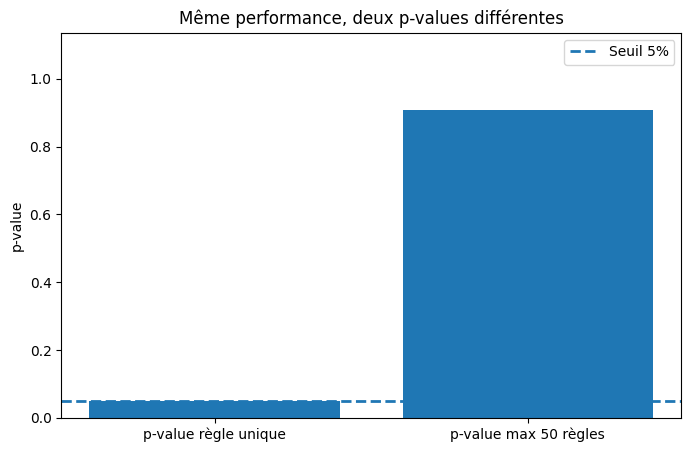

In [7]:
labels = ['p-value règle unique', f'p-value max {N_rules} règles']
values = [p_value_single, p_value_max]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.axhline(0.05, linestyle='--', linewidth=2, label='Seuil 5%')
plt.title('Même performance, deux p-values différentes')
plt.ylabel('p-value')
plt.ylim(0, max(values) * 1.25)
plt.legend()
plt.show()


## 8. Effet du nombre de règles testées

Plus on teste de règles, plus le meilleur résultat obtenu par hasard augmente.

C’est exactement le mécanisme du **biais de sélection**.

On peut l’observer en faisant varier le nombre de règles candidates.


In [8]:
rule_counts = [1, 5, 10, 25, 50, 100, 250, 500]
rows = []

for n_rules in rule_counts:
    sims = rng.normal(loc=0.0, scale=sigma, size=(n_sim, n_rules, T))
    means = sims.mean(axis=2)
    maxima = means.max(axis=1)
    rows.append({
        'Nombre de règles testées': n_rules,
        'Moyenne du meilleur résultat': maxima.mean(),
        'Médiane du meilleur résultat': np.median(maxima),
        'Percentile 95% du meilleur résultat': np.percentile(maxima, 95),
    })

effect_df = pd.DataFrame(rows)
effect_df


,Nombre de règles testées,Moyenne du meilleur résultat,Médiane du meilleur résultat,Percentile 95% du meilleur résultat
0,1,0.000004,2.886897e-07,0.001043
1,5,0.000731,7.138322e-04,0.001451
2,10,0.000973,9.471835e-04,0.001605
3,25,0.001236,1.207756e-03,0.001806
4,50,0.001421,1.395343e-03,0.001948
5,100,0.001582,1.554872e-03,0.002063
6,250,0.001772,1.746328e-03,0.002211
7,500,0.001915,1.884653e-03,0.002347


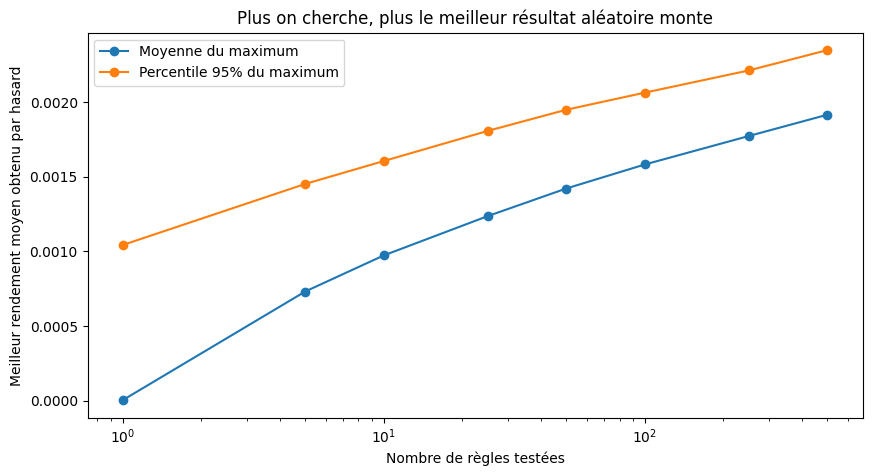

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(effect_df['Nombre de règles testées'], effect_df['Moyenne du meilleur résultat'], marker='o', label='Moyenne du maximum')
plt.plot(effect_df['Nombre de règles testées'], effect_df['Percentile 95% du meilleur résultat'], marker='o', label='Percentile 95% du maximum')
plt.xscale('log')
plt.title('Plus on cherche, plus le meilleur résultat aléatoire monte')
plt.xlabel('Nombre de règles testées')
plt.ylabel('Meilleur rendement moyen obtenu par hasard')
plt.legend()
plt.show()


## 9. Mini White's Reality Check simplifié

Le **White's Reality Check** vise à tester si la meilleure règle trouvée bat réellement ce que le hasard aurait pu produire après une recherche multiple.

Version simplifiée de l’idée :

1. On observe les performances de plusieurs règles.
2. On conserve le meilleur résultat.
3. On génère une distribution de référence du **maximum** sous $H_0$.
4. On compare le meilleur résultat observé à cette distribution.

Ce notebook ne remplace pas une implémentation complète du WRC, mais il montre l’intuition essentielle : il faut comparer un maximum à une distribution de maximum.


In [10]:
def reality_check_p_value(observed_rule_returns, n_bootstrap=5000, seed=123):
    """
    Version pédagogique simplifiée d'un Reality Check.

    observed_rule_returns : array de forme (N_rules, T)
        Rendements historiques des règles candidates.

    n_bootstrap : int
        Nombre de simulations bootstrap.

    Retourne :
        meilleur rendement moyen observé,
        p-value corrigée par comparaison avec une distribution du maximum.
    """
    local_rng = np.random.default_rng(seed)
    observed_means = observed_rule_returns.mean(axis=1)
    observed_best = observed_means.max()

    # Centrage des rendements pour imposer H0 : pas d'edge moyen
    centered = observed_rule_returns - observed_rule_returns.mean(axis=1, keepdims=True)
    n_rules, T_local = centered.shape

    bootstrap_maxima = []
    for _ in range(n_bootstrap):
        idx = local_rng.integers(0, T_local, size=T_local)
        sample = centered[:, idx]
        bootstrap_maxima.append(sample.mean(axis=1).max())

    bootstrap_maxima = np.array(bootstrap_maxima)
    p_value = np.mean(bootstrap_maxima >= observed_best)

    return observed_best, p_value, bootstrap_maxima

# Créons un faux univers de 50 règles sans edge réel
observed_rules = rng.normal(loc=0.0, scale=sigma, size=(50, T))
observed_best, corrected_p, bootstrap_maxima = reality_check_p_value(observed_rules)

observed_best, corrected_p


(np.float64(0.0014547656713423754), np.float64(0.4036))

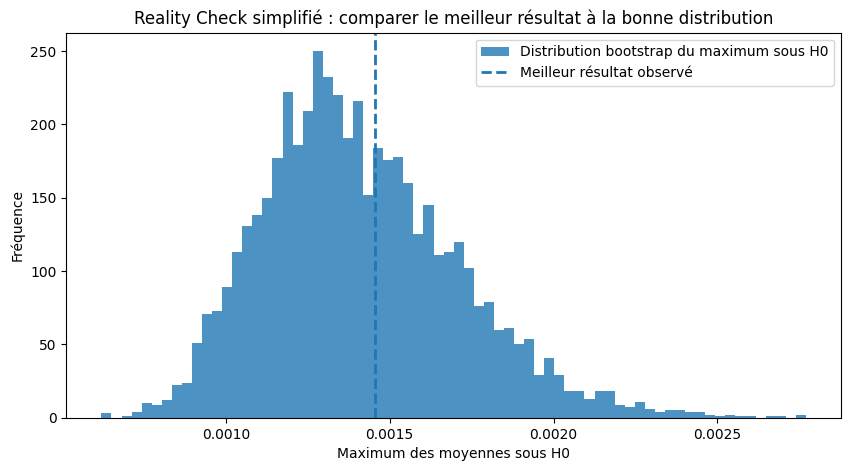

In [11]:
plt.figure(figsize=(10, 5))
plt.hist(bootstrap_maxima, bins=70, alpha=0.8, label='Distribution bootstrap du maximum sous H0')
plt.axvline(observed_best, linestyle='--', linewidth=2, label='Meilleur résultat observé')
plt.title("Reality Check simplifié : comparer le meilleur résultat à la bonne distribution")
plt.xlabel('Maximum des moyennes sous H0')
plt.ylabel('Fréquence')
plt.legend()
plt.show()


## 10. Exemple trading : pourquoi un beau backtest peut être nul

Imaginons qu’un trader teste 200 variantes d’une stratégie :

- différentes périodes de moyennes mobiles ;
- différents filtres de volatilité ;
- différentes heures d’entrée ;
- différents take-profits et stop-loss ;
- différents marchés ou timeframes.

À la fin, il garde la variante qui affiche le meilleur backtest.

Le résultat final n’est pas une preuve directe d’edge.

C’est d’abord le **champion d’un tournoi statistique**.

> **L’Eurêka final :** une stratégie optimisée doit battre le hasard optimisé, pas seulement le hasard simple.


## 11. Checklist EBTA avant de croire une p-value

| Question | Pourquoi c’est important |
|---|---|
| Ai-je testé une seule règle définie à l’avance ? | Une p-value classique peut être pertinente. |
| Ai-je testé plusieurs variantes ? | Il faut corriger le biais de sélection. |
| Ai-je gardé seulement le meilleur résultat ? | La statistique observée est un maximum. |
| Ai-je changé les paramètres après avoir vu les résultats ? | Cela transforme le test en recherche de spécification. |
| Ai-je utilisé une distribution du maximum ? | C’est nécessaire pour une inférence correcte. |
| Ai-je validé hors échantillon ? | Cela réduit le risque d’illusion statistique. |


## 12. Résumé final

Une **distribution d’échantillonnage** n’est pas un détail technique.

C’est le tribunal statistique devant lequel on juge une stratégie.

Si on présente une stratégie issue du **data mining** devant le tribunal d’une **règle unique**, on obtient un verdict trop favorable.

La bonne question n’est pas :

> Cette stratégie gagne-t-elle plus que zéro ?

La bonne question est :

> Cette stratégie gagne-t-elle plus que ce que le meilleur résultat d’une recherche aléatoire aurait pu produire ?

C’est ce changement de question qui sépare une illusion de backtest d’une inférence statistique solide.


## Annexe — Source originale collée par l’utilisateur

Le texte ci-dessous est conservé comme référence brute pour garder la traçabilité du notebook.


### **CH 6 : SOUND INFERENCE REQUIRES THE CORRECT SAMPLING DISTRIBUTION**

Voici l’analyse technique de l’importance d’utiliser la distribution d’échantillonnage appropriée pour valider une règle de trading, particulièrement lorsque celle-ci est issue du minage de données.

#### **Idées clés :**
*   **Adéquation Statistique :** Une inférence n'est valide que si la distribution d'échantillonnage utilisée correspond exactement à la statistique observée (Page 276).
*   **Moyenne vs Maximum :** Tester une règle unique revient à observer une *moyenne* ; pratiquer le minage de données revient à observer le *maximum* parmi une multitude de moyennes (Page 275).
*   **Déplacement du Centre :** La distribution d'échantillonnage du maximum de $N$ moyennes n'est pas centrée sur zéro, mais sur une valeur positive qui reflète le profit espéré par pur hasard lors de recherches intensives (Page 277).
*   **Le Piège de la P-value Classique :** Utiliser une distribution de "règle unique" pour évaluer un résultat de minage de données conduit à rejeter l'Hypothèse Nulle ($H_0$) à tort, créant des illusions de talent (Page 277).

#### **Référence :**
*Sound Inference Requires the Correct Sampling Distribution*, Chapitre 6, pages 276 à 278.

#### **Citation Directe :**
« Sound statistical inference depends on using the correct sampling distribution. Each test statistic has a sampling distribution that is appropriate for testing its statistical significance. The sampling distribution that would be correct for testing the significance of a single sample mean [...] would not be correct if the test statistic being observed were, in fact, a maximum mean among a multitude of sample means. » (Page 276).

#### **Vision Macro :**
L'enjeu est l'intégrité de la preuve. David Aronson explique que la statistique n'est pas une formule magique universelle, mais un instrument de précision. Si le trader change sa méthode de recherche (en passant d'un test unique à une sélection parmi des milliers de variantes), il doit impérativement changer son instrument de mesure (la distribution d'échantillonnage). Ne pas le faire revient à utiliser une règle graduée en centimètres pour mesurer des années-lumière : le résultat final est mathématiquement absurde et conduit à trader du "métal des fous" (*Fool's Gold*).

#### **Vision Micro :**
Le mécanisme de l'inférence correcte repose sur la comparaison du résultat avec la bonne "cloche" de probabilité :

1.  **Le test traditionnel (Figure 6.9) :** On suppose qu'une règle a un profit de +37 % issu d'un test sur 50 règles. Si on utilise la distribution classique centrée sur zéro, ce +37 % tombe très loin dans la queue droite. La p-value est alors < 0,05, et le trader conclut (à tort) que la règle est géniale.
2.  **Le test corrigé (Figure 6.10) :** On utilise la distribution du *maximum* pour 50 règles. Dans cet univers, le hasard produit "naturellement" un gagnant à +33 % (centre de la nouvelle distribution). Le profit de +37 % se retrouve alors au milieu de la cloche.
3.  **Le verdict :** Avec la distribution correcte, la p-value remonte à plus de 0,45. Cela prouve que le profit de +37 % n'est pas un signe de talent, mais un événement parfaitement ordinaire pour quelqu'un qui teste 50 règles nulles.

#### **Résumé Simplifié :**
Imaginez un concours de tir à l'arc. Si un inconnu tire une flèche et touche le centre, c'est impressionnant (règle unique). Mais si vous demandez à 1 000 personnes de tirer, l'une d'elles touchera forcément le centre par pur hasard (minage de données). Pour savoir si cette personne a du talent, vous ne devez pas comparer son tir à celui d'un débutant, mais aux performances habituelles des "gagnants par chance". En trading, votre "meilleure" stratégie doit battre le record de la chance, pas seulement rapporter de l'argent.

#### **Exemples du livre pour mieux comprendre :**
*   **L'exemple des 50 règles :** Aronson démontre qu'un profit de **37 %** semble "hautement significatif" (p-value < 0,05) si on ignore le minage, mais devient "totalement insignifiant" (p-value > 0,45) dès qu'on le compare à la distribution du maximum de 50 essais.
*   **L'étude de cas S&P 500 :** Le meilleur rendement trouvé était de **10,25 %**. Sans correction, il paraissait miraculeux (p-value = 0,0005). Après application du White's Reality Check (qui utilise la distribution du maximum), la p-value est montée à **0,81**, révélant une absence totale de pouvoir prédictif.

#### **Actions Concrètes :**
*   **Identifier la source :** Avant d'analyser une p-value, demandez-vous : "Est-ce le résultat d'une seule idée ou le maximum d'une optimisation ?".
*   **Cesser d'utiliser les tests T classiques :** Ne s'appliquent pas aux stratégies optimisées car ils ne tiennent pas compte du biais de sélection.
*   **Utiliser le White's Reality Check (WRC) :** C'est l'outil recommandé pour générer la distribution du maximum et obtenir une p-value honnête.
*   **Surélever les seuils d'acceptation :** Admettez qu'une stratégie peut gagner 15 % ou 20 % en backtest et être statistiquement "nulle" si l'univers de recherche était trop vaste.

#### **À retenir absolument :**
*   **Distribution correcte = Inférence valide.**
*   Le minage de données déplace le **seuil de la chance** vers des profits élevés.
*   Un profit de backtest "significatif" est souvent une **erreur de Type I** (faux positif).
*   Le **Maximum** est une statistique différente de la **Moyenne**.
*   Le succès passé d'un "champion" est structurellement **biaisé à la hausse**.

J'ai terminé l'analyse de la nécessité d'une distribution d'échantillonnage correcte selon le protocole EBTA.
